# Artificial Immune System — Detector Evolution Experiments

This notebook studies how a population of binary detectors evolves
to recognise a fixed pathogen while avoiding self-reactivity.

Three sweeps are run:
  - Experiment 1 : easy pathogen (all 1s) vs hard pathogen (mixed bits)
  - Experiment 2 : parameter sweep — R, detectors per individual, detector length
  - Experiment 3 : mutation rate sweep with four diagnostic metrics


## 0. Imports

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

## 1. Shared primitives

All functions here are pure (no global state) so every experiment can
call them with its own parameters without interference.

In [2]:
def random_bitstring(n, rng):
    """Return a random binary string of length n using the given RNG."""
    return ''.join(rng.choice("01") for _ in range(n))


def r_contiguous_match(a, b, r):
    """
    Return True if strings a and b share a run of r or more identical
    bits at the same positions.

    This is the r-contiguous matching rule from the AIS literature.
    A short r means almost anything matches; a large r is very selective.
    """
    run = 0
    for x, y in zip(a, b):
        if x == y:
            run += 1
            if run >= r:
                return True
        else:
            run = 0
    return False


def split_chromosome(chrom, detector_length):
    """
    Treat the chromosome as one long bitstring and slice it into
    equal-length detector blocks.

    This 'evolving representation' approach lets standard crossover
    operate across detector boundaries, creating novel detector patterns
    that a detector-level crossover could not reach.
    """
    n = len(chrom) // detector_length
    return [chrom[i * detector_length:(i + 1) * detector_length]
            for i in range(n)]


def mutate(bitstring, rate, rng):
    """Flip each bit independently with probability `rate`."""
    bits = list(bitstring)
    for i in range(len(bits)):
        if rng.random() < rate:
            bits[i] = '1' if bits[i] == '0' else '0'
    return ''.join(bits)


def crossover(p1, p2, rng):
    """Single-point crossover at a random interior position."""
    cut = rng.randint(1, len(p1) - 1)
    return p1[:cut] + p2[cut:]


def tournament(population, fitnesses, k, rng):
    """
    Tournament selection: sample k individuals at random and return
    the one with the highest fitness.

    Higher k = stronger selection pressure.
    """
    idx = rng.sample(range(len(population)), k)
    return population[max(idx, key=lambda i: fitnesses[i])]

## 2. Fitness function

Two-stage evaluation:

**Stage 1 — Negative selection**
Each detector is tested against the self string.  Any detector that
matches self (r-contiguous) is considered self-reactive and is
excluded from the count of useful detectors.

**Stage 2 — Pathogen coverage**
Among the surviving (non-self-reactive) detectors, count how many
match the pathogen.

**Fitness formula**

    fitness = n_detecting / n_total

The denominator is the *total* number of detectors, not just the
valid ones.  This means self-reactive detectors actively hurt the
individual's score even if the remaining detectors all fire correctly.
It gives negative selection a direct gradient in the fitness landscape.

In [3]:
def evaluate(chrom, pathogen, self_str, r, detector_length):
    """
    Returns
    -------
    fitness        : float  0..1   primary optimisation target
    n_valid        : int    detectors that passed negative selection
    n_detecting    : int    valid detectors that matched the pathogen
    """
    detectors = split_chromosome(chrom, detector_length)
    n_total = len(detectors)

    # Stage 1: keep only self-tolerant detectors
    valid = [d for d in detectors
             if not r_contiguous_match(d, self_str, r)]
    n_valid = len(valid)

    # Stage 2: count pathogen recognition among valid detectors
    n_detecting = sum(
        1 for d in valid
        if r_contiguous_match(d, pathogen, r)
    )

    fitness = n_detecting / n_total
    return fitness, n_valid, n_detecting

## 3. GA engine

Standard generational GA with:
  - Elitism   : top `elite` individuals copied unchanged
  - Selection : tournament of size `tournament_k`
  - Variation : single-point crossover then per-bit mutation

The mutation rate defaults to 1/chromosome_length, the classical
setting that expects roughly one bit-flip per offspring.  It is
exposed as a parameter so Experiment 3 can override it.

In [4]:
def run_ga(pathogen, self_str, r, detector_length, detectors_per_ind,
           pop_size=100, generations=80, elite=5, tournament_k=3,
           mutation_rate=None, seed=42):
    """
    Run the GA and return a history array of shape (generations, 4):
        col 0 : mean fitness
        col 1 : best fitness
        col 2 : mean fraction of detectors surviving negative selection
        col 3 : mean fraction of detectors that recognised the pathogen
    """
    rng_local = random.Random(seed)
    chrom_len = detector_length * detectors_per_ind

    # Default: one expected bit-flip per chromosome
    if mutation_rate is None:
        mutation_rate = 1.0 / chrom_len

    population = [random_bitstring(chrom_len, rng_local)
                  for _ in range(pop_size)]
    history = []

    for _ in range(generations):
        evals = [evaluate(c, pathogen, self_str, r, detector_length)
                 for c in population]

        fitnesses        = [e[0] for e in evals]
        valid_fracs      = [e[1] / detectors_per_ind for e in evals]
        detecting_fracs  = [e[2] / detectors_per_ind for e in evals]

        history.append((
            float(np.mean(fitnesses)),
            float(np.max(fitnesses)),
            float(np.mean(valid_fracs)),
            float(np.mean(detecting_fracs)),
        ))

        # Elitism: preserve top individuals unchanged
        ranked   = sorted(range(pop_size),
                          key=lambda i: fitnesses[i], reverse=True)
        next_pop = [population[i] for i in ranked[:elite]]

        # Fill the rest via tournament selection + crossover + mutation
        while len(next_pop) < pop_size:
            p1    = tournament(population, fitnesses, tournament_k, rng_local)
            p2    = tournament(population, fitnesses, tournament_k, rng_local)
            child = mutate(crossover(p1, p2, rng_local), mutation_rate, rng_local)
            next_pop.append(child)

        population = next_pop

    return np.array(history)

## 4. Plotting helpers

In [5]:
def plot_single(hist, title, filename=None):
    """Four-panel diagnostic plot for one GA run.
    If filename is provided, saves the plot to that file.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    axes = axes.flatten()

    panels = [
        (1, "Best fitness",                          "Fitness"),
        (0, "Mean fitness",                          "Fitness"),
        (2, "Valid detectors (post negative sel.)",  "Fraction"),
        (3, "Detecting detectors (fired on pathogen)", "Fraction"),
    ]

    for ax, (col, subtitle, ylabel) in zip(axes, panels):
        ax.plot(hist[:, col])
        ax.set_title(subtitle, fontsize=11)
        ax.set_xlabel("Generation")
        ax.set_ylabel(ylabel)
        if col in (2, 3):
            ax.set_ylim(0, 1)
        ax.grid(alpha=0.4)

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    if filename:
        plt.savefig(filename)
        print(f"Plot saved as '{filename}'")
    plt.show()


def plot_sweep(results_dict, col, title, ylabel, ylim=None, filename=None):
    """Overlay one metric for multiple parameter values.
    If filename is provided, saves the plot to that file.
    """
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, hist in results_dict.items():
        ax.plot(hist[:, col], label=str(label))
    ax.set_title(title)
    ax.set_xlabel("Generation")
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.4)
    plt.tight_layout()
    if filename:
        plt.savefig(filename)
        print(f"Plot saved as '{filename}'")
    plt.show()


def plot_four_metrics(results_dict, suptitle, filename=None):
    """Four-panel sweep plot, one panel per metric.
    If filename is provided, saves the plot to that file.
    """
    panels = [
        (1, "Best fitness",                           "Fitness",   None),
        (0, "Mean fitness",                           "Fitness",   None),
        (2, "Valid detectors (survived neg. sel.)",   "Fraction",  (0, 1)),
        (3, "Detecting detectors (fired on pathogen)","Fraction",  (0, 1)),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()

    for ax, (col, title, ylabel, ylim) in zip(axes, panels):
        for label, hist in results_dict.items():
            ax.plot(hist[:, col], label=str(label))
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Generation")
        ax.set_ylabel(ylabel)
        if ylim:
            ax.set_ylim(*ylim)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.4)

    fig.suptitle(suptitle, fontsize=13, y=1.01)
    plt.tight_layout()
    if filename:
        plt.savefig(filename)
        print(f"Plot saved as '{filename}'")
    plt.show()

---
## Experiment 1 — Easy vs hard pathogen

**Setup**
- Detector length  = 10 bits
- Detectors / ind  = 10
- R                = 8
- Self             = 0000000000
- Pathogen A       = 1111111111  (maximally different from self)
- Pathogen B       = 1100110110  (mixed — shares some bits with self)


Pathogen A should be easier: any detector biased toward 1s both
avoids self and recognises the pathogen.  Pathogen B forces the GA
to find detectors that match a specific mixed pattern without
accidentally matching the all-zeros self string.

Plot saved as 'experiment1a_pathogen_a.png'


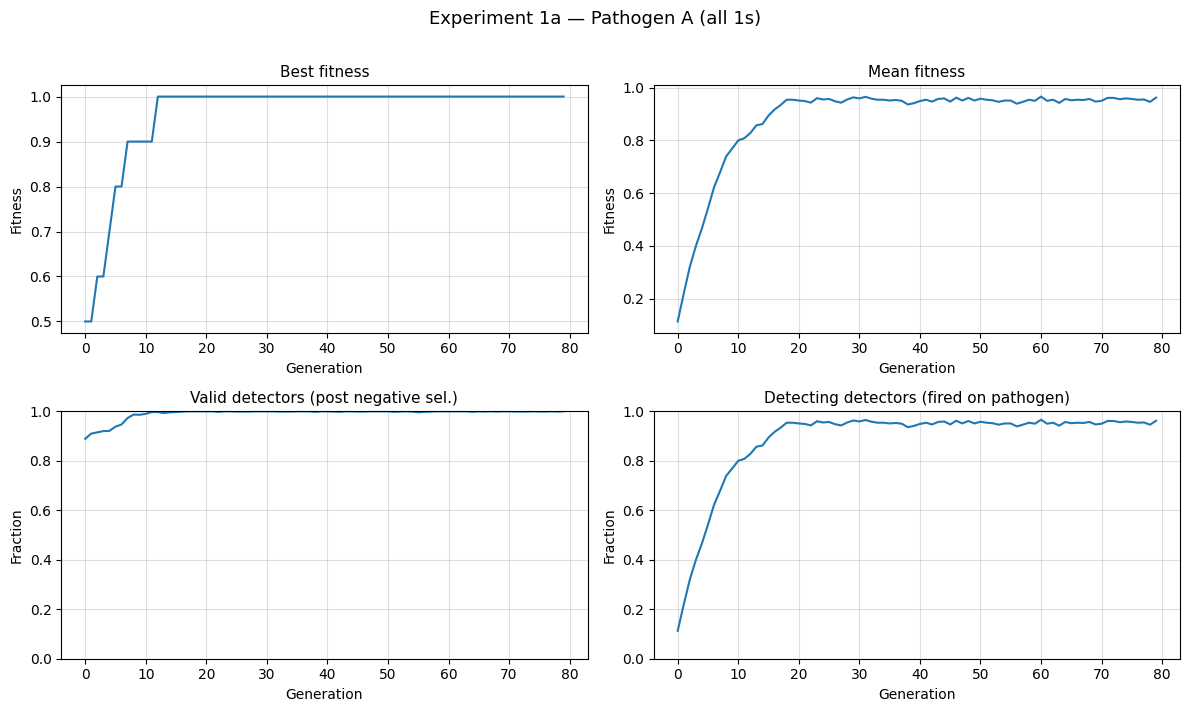

Plot saved as 'experiment1b_pathogen_b.png'


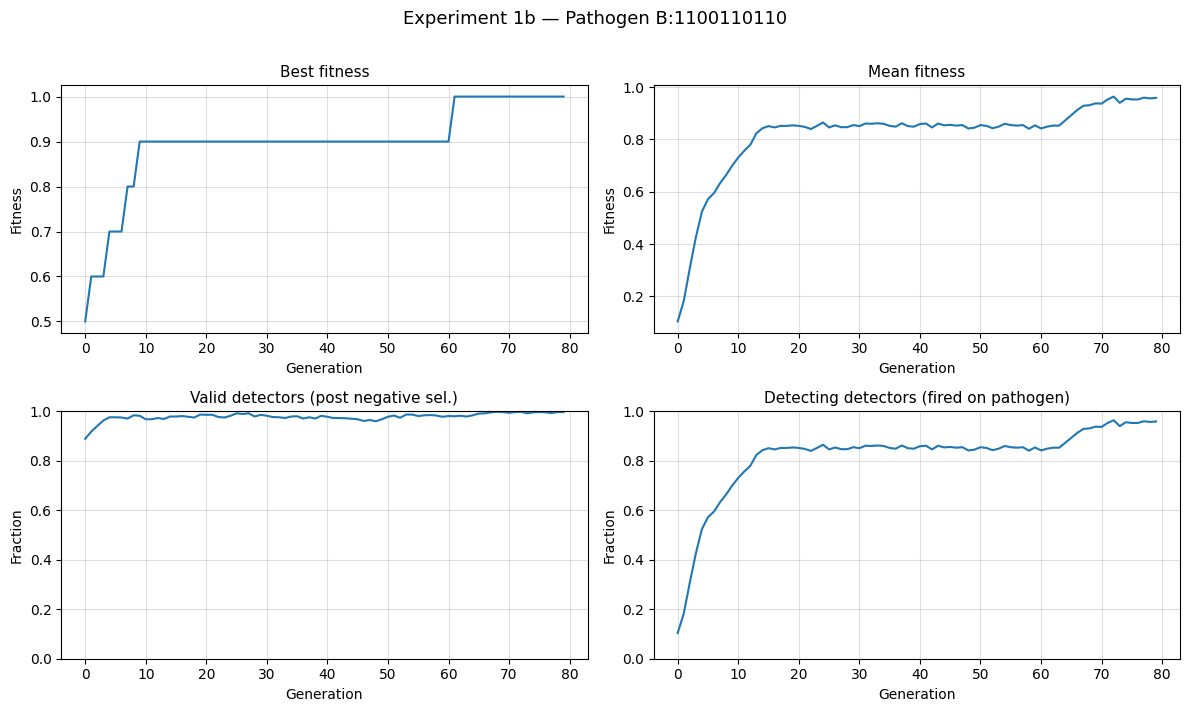

Plot saved as 'experiment1_best_fitness_comparison.png'


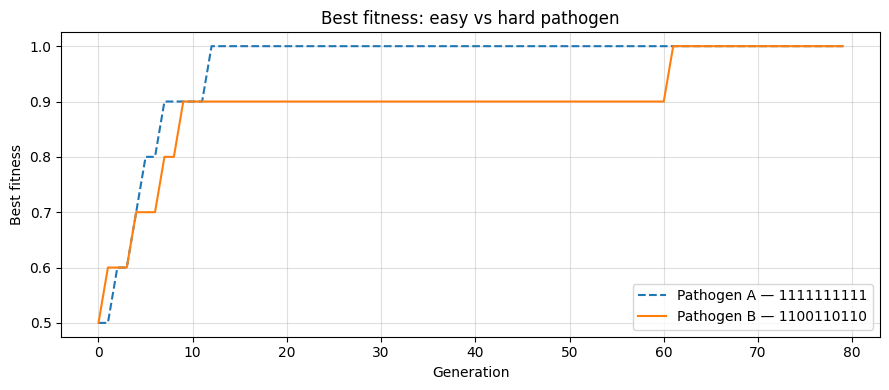

Plot saved as 'experiment1_detecting_fraction_comparison.png'


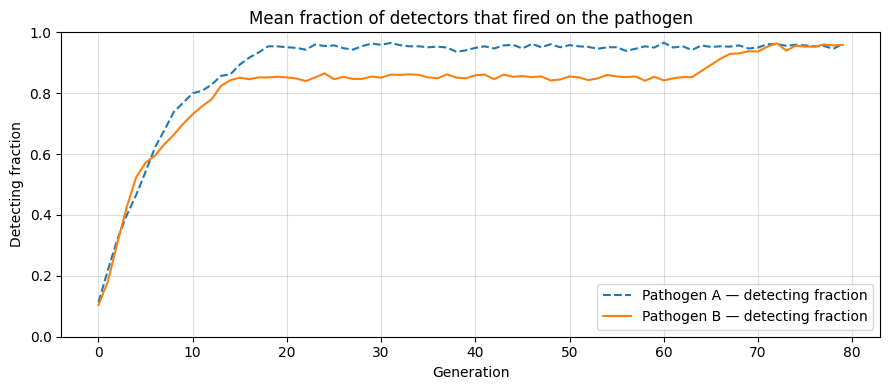

In [6]:
DETECTOR_LENGTH = 10 # Each detector is 10 bits long
DETECTORS_PER_IND = 10 # There are 10 detectors per individual
R = 5 # R-contiguous match threshold

# Total chromosome length will be DETECTOR_LENGTH * DETECTORS_PER_IND = 10 * 10 = 100

SELF = "0" * DETECTOR_LENGTH
PAT_A = "1" * DETECTOR_LENGTH          # all ones, matches DETECTOR_LENGTH
PAT_B = "1100110110"                     # mixed — must match DETECTOR_LENGTH (now 10 bits)

BASE = dict(
    r                 = R,
    detector_length   = DETECTOR_LENGTH,
    detectors_per_ind = DETECTORS_PER_IND,
    pop_size          = 100,
    elite             = 5,
    tournament_k      = 3,
    seed              = 42,
)

hist_a = run_ga(pathogen=PAT_A, self_str=SELF, generations=80, **BASE)
hist_b = run_ga(pathogen=PAT_B, self_str=SELF, generations=80, **BASE)

plot_single(hist_a, "Experiment 1a — Pathogen A (all 1s)", filename='experiment1a_pathogen_a.png')
plot_single(hist_b, "Experiment 1b — Pathogen B:1100110110", filename='experiment1b_pathogen_b.png')

# Direct comparison of best fitness
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hist_a[:, 1], label=f"Pathogen A — {'1'*DETECTOR_LENGTH}", linestyle="--")
ax.plot(hist_b[:, 1], label=f"Pathogen B — {PAT_B}", linestyle="-")
ax.set_title("Best fitness: easy vs hard pathogen")
ax.set_xlabel("Generation")
ax.set_ylabel("Best fitness")
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('experiment1_best_fitness_comparison.png')
print("Plot saved as 'experiment1_best_fitness_comparison.png'")
plt.show()

# Direct comparison of detecting fraction
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hist_a[:, 3], label="Pathogen A — detecting fraction", linestyle="--")
ax.plot(hist_b[:, 3], label="Pathogen B — detecting fraction", linestyle="-")
ax.set_title("Mean fraction of detectors that fired on the pathogen")
ax.set_xlabel("Generation")
ax.set_ylabel("Detecting fraction")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('experiment1_detecting_fraction_comparison.png')
print("Plot saved as 'experiment1_detecting_fraction_comparison.png'")
plt.show()

---
## Experiment 2 — Parameter sweep

Three sub-sweeps on Pathogen A (all 1s) to isolate the effect of each
structural parameter.  All other parameters are held at the BASE values.

### 2a — Effect of R (contiguity threshold)
R controls how strict the matching rule is.
  

Plot saved as 'experiment2a_effect_of_r.png'


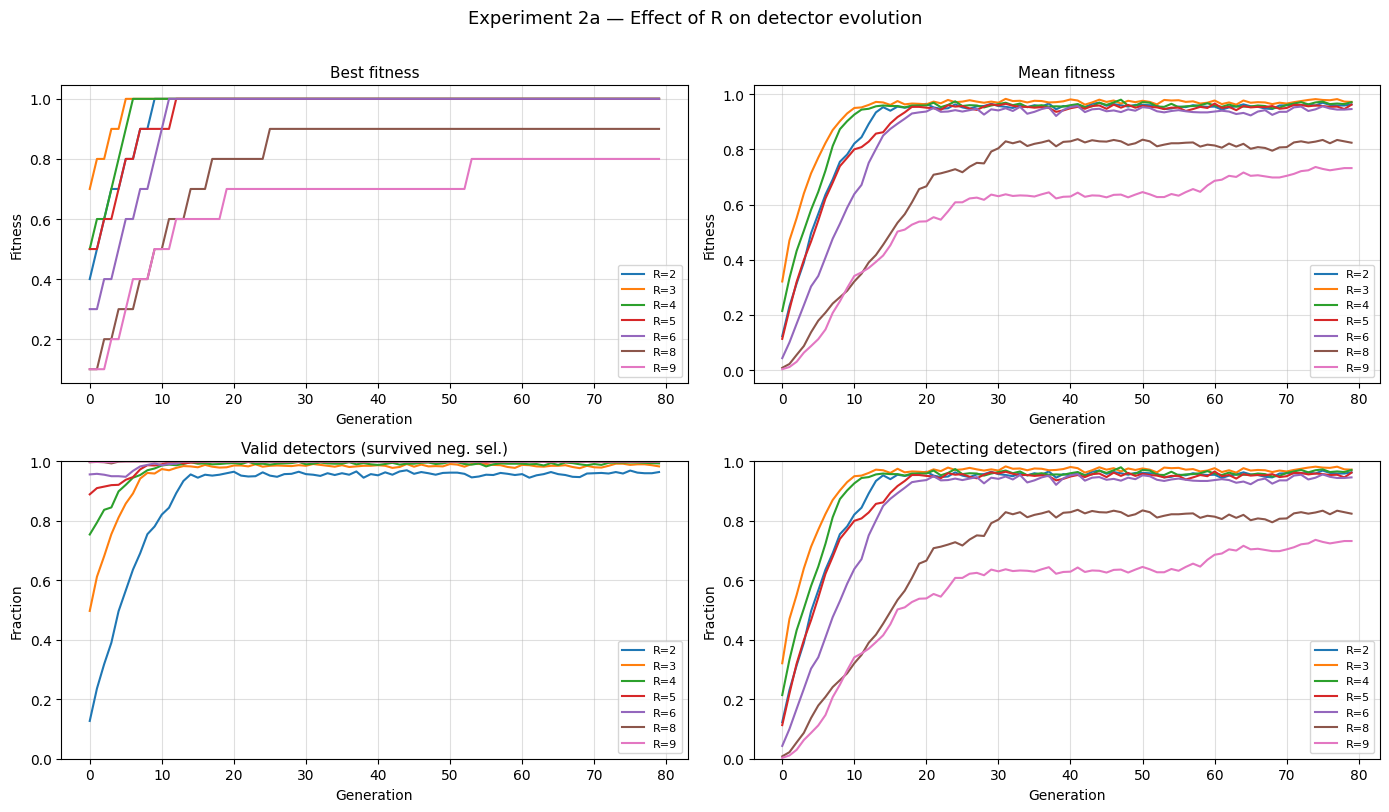

In [7]:
r_results = {}
for r_val in [2, 3, 4, 5, 6,8,9]:
    cfg = dict(BASE, r=r_val)
    r_results[f"R={r_val}"] = run_ga(pathogen=PAT_A, self_str=SELF,
                                      generations=80, **cfg)

plot_four_metrics(r_results, "Experiment 2a — Effect of R on detector evolution", filename='experiment2a_effect_of_r.png')

Plot saved as 'experiment2aa_effect_of_r.png'


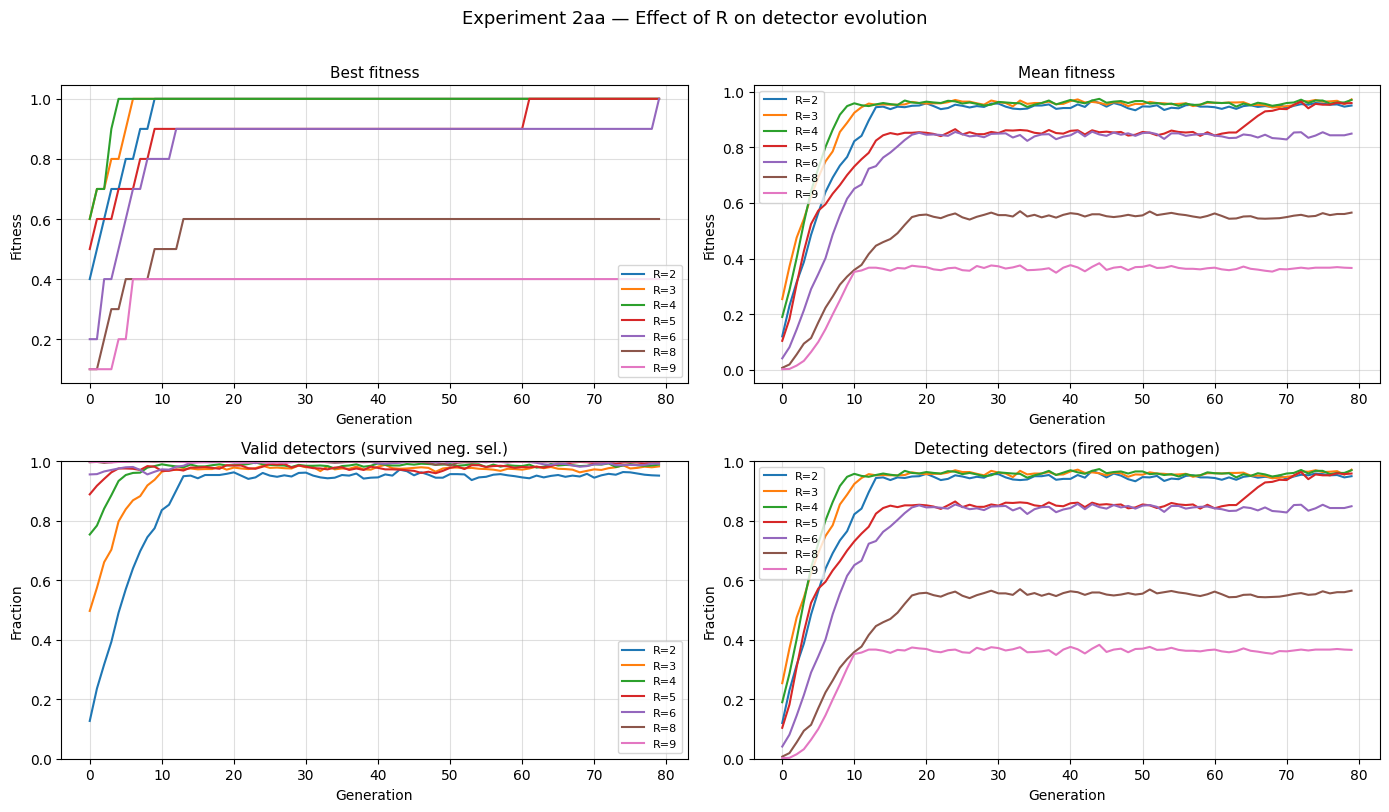

In [8]:
r_results = {}
for r_val in [2, 3, 4, 5, 6,8,9]:
    cfg = dict(BASE, r=r_val)
    r_results[f"R={r_val}"] = run_ga(pathogen=PAT_B, self_str=SELF,
                                      generations=80, **cfg)

plot_four_metrics(r_results, "Experiment 2aa — Effect of R on detector evolution", filename='experiment2aa_effect_of_r.png')

### 2b — Effect of detectors per individual
More detectors give the immune system more coverage but also a larger
chromosome to evolve.  Watch whether the detecting fraction grows with
detector count or whether the GA struggles to optimise longer chromosomes.

Plot saved as 'experiment2b_effect_detectors_per_individual.png'


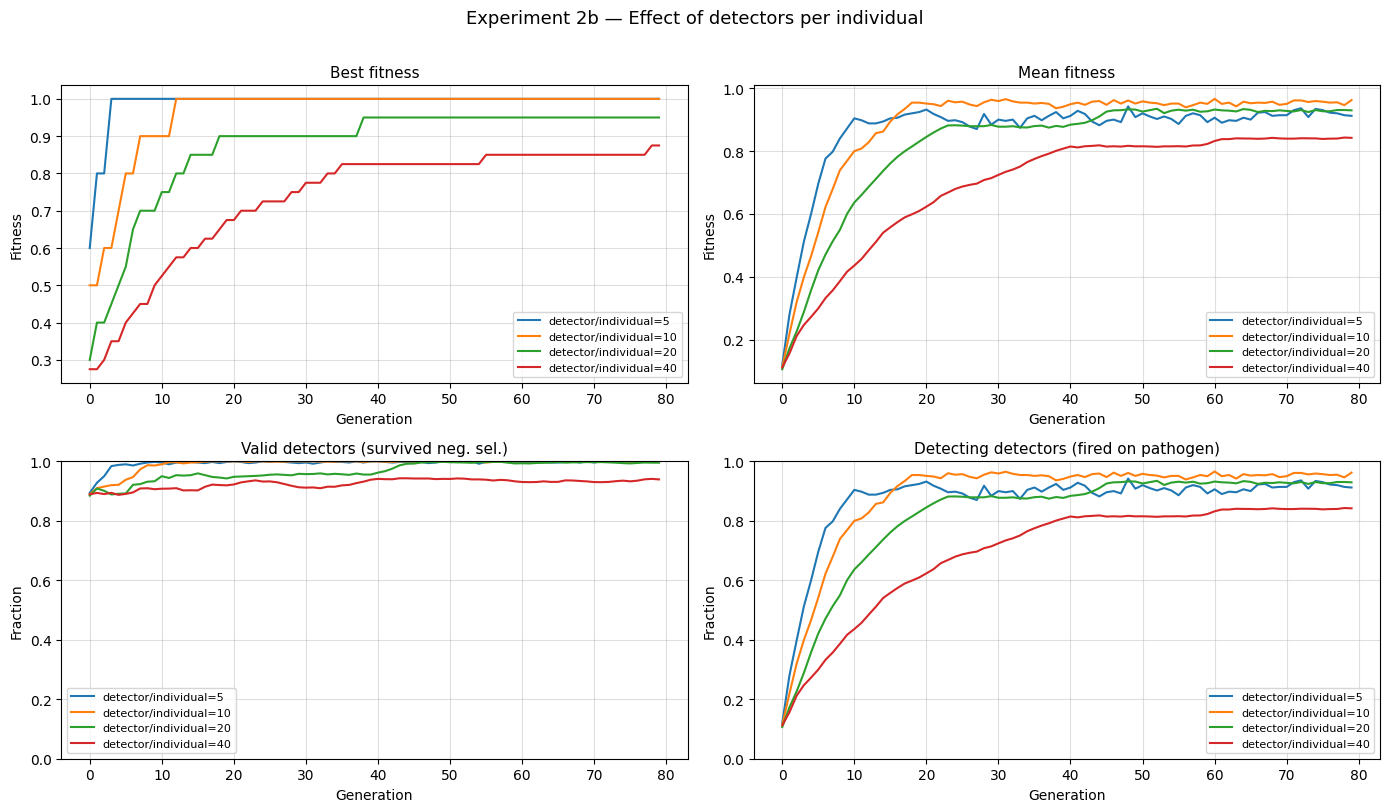

In [9]:
det_results = {}
for n_det in [5, 10, 20, 40]:
    cfg = dict(BASE, detectors_per_ind=n_det)
    det_results[f"detector/individual={n_det}"] = run_ga(pathogen=PAT_A, self_str=SELF,
                                              generations=80, **cfg)

plot_four_metrics(det_results,
                  "Experiment 2b — Effect of detectors per individual", filename='experiment2b_effect_detectors_per_individual.png')

### 2c — Effect of detector length
Longer detectors are more specific (harder to match by chance) but the
search space grows exponentially and the GA needs more generations or
population to explore it.  The pathogen is resized to match the detector
length in each run.

Plot saved as 'experiment2c_effect_detector_length.png'


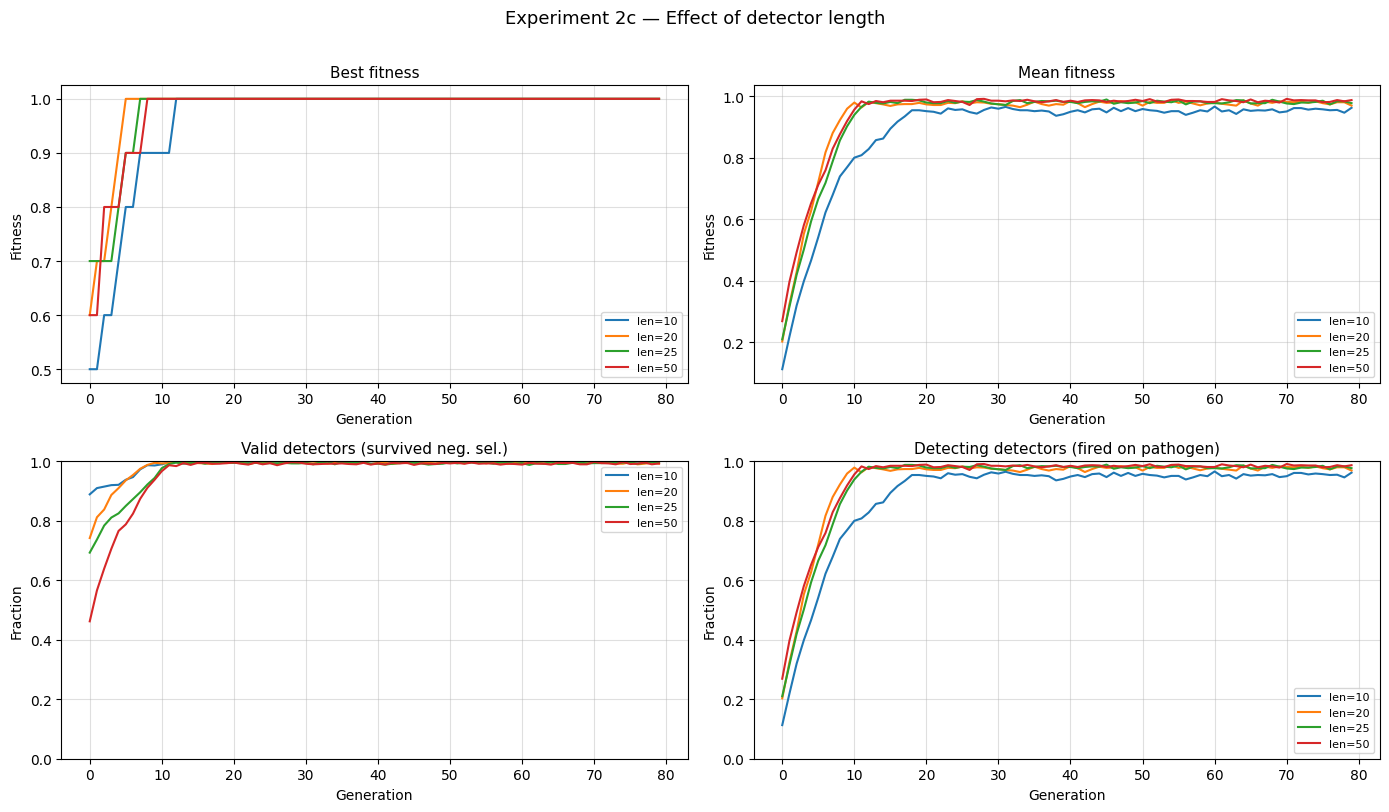

In [10]:
len_results = {}
for dl in [10, 20, 25, 50]:
    cfg      = dict(BASE, detector_length=dl)
    pathogen = "1" * dl
    self_str = "0" * dl
    len_results[f"len={dl}"] = run_ga(pathogen=pathogen, self_str=self_str,
                                       generations=80, **cfg)

plot_four_metrics(len_results, "Experiment 2c — Effect of detector length", filename='experiment2c_effect_detector_length.png')

---
## Experiment 3 — Mutation rate sweep

Mutation has a unique dual role in this system:

1. **Exploration** — bit flips allow detectors to escape self-reactive
    patterns and search for pathogen-matching ones.
2. **Disruption** — every bit flip on a valid detector risks creating a
    run of zeros that triggers self-reactivity, removing the detector
    from the pool entirely.

This means the valid-detector fraction is a sensitive signal: high
mutation actively destroys self-tolerance at the population level.

Six rates are tested from 0 (no mutation) to 0.5 (near-random).
The standard rate 1/L is included as the reference.

Plot saved as 'experiment3-PA_mutation_rate_sweep.png'


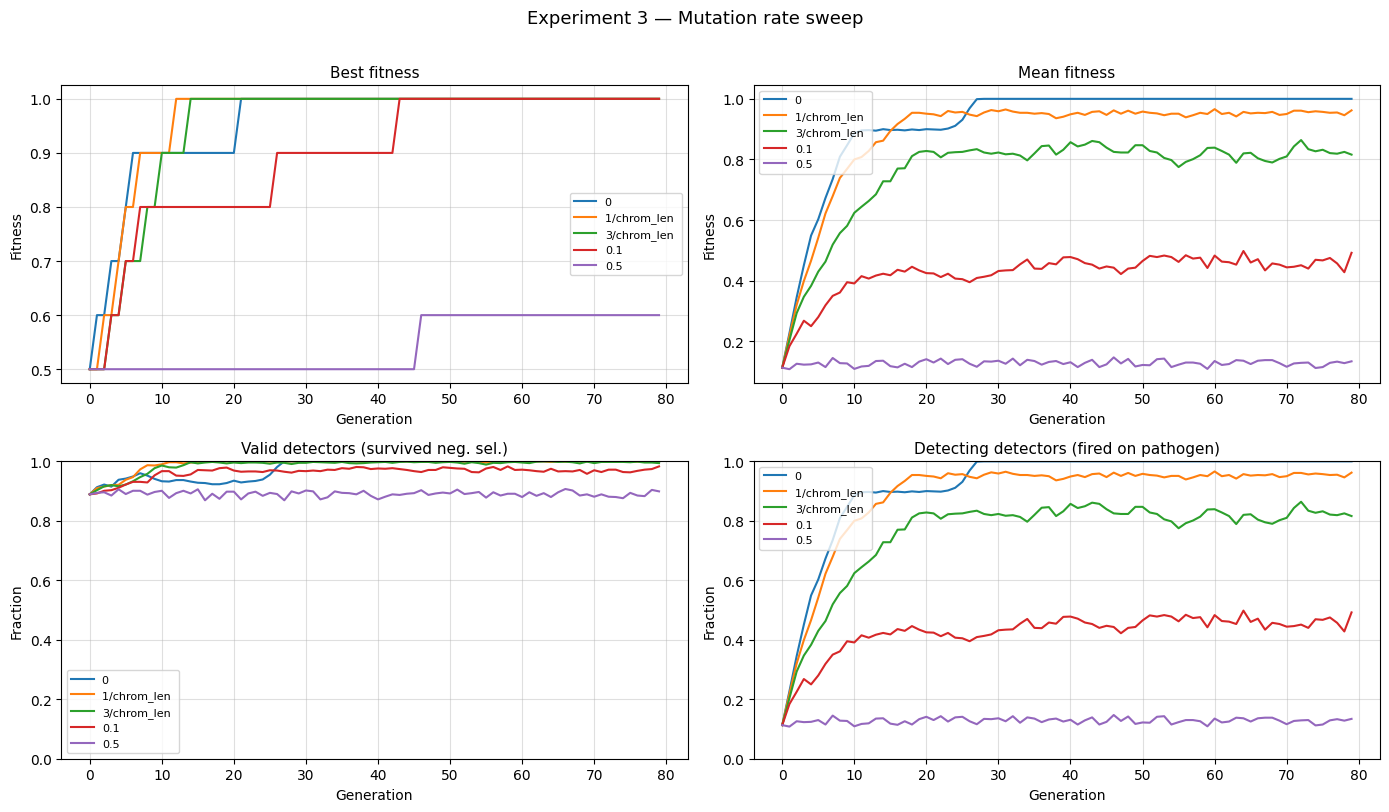

In [11]:
chrom_len = BASE["detector_length"] * BASE["detectors_per_ind"]

mutation_rates = {
    "0 ":        0.0,
    "1/chrom_len ": 1.0 / (2 * chrom_len),
    "1/chrom_len ":  1.0 / chrom_len,
    "3/chrom_len":      3.0 / chrom_len,
    "0.1": 0.1,
    "0.5": 0.5,
}

mut_results = {}
for label, rate in mutation_rates.items():
    mut_results[label] = run_ga(
        pathogen      = PAT_A,
        self_str      = SELF,
        generations   = 80,
        mutation_rate = rate,
        **BASE,
    )

plot_four_metrics(mut_results, "Experiment 3 — Mutation rate sweep", filename='experiment3-PA_mutation_rate_sweep.png')

Plot saved as 'experiment3_mutation_rate_sweep.png'


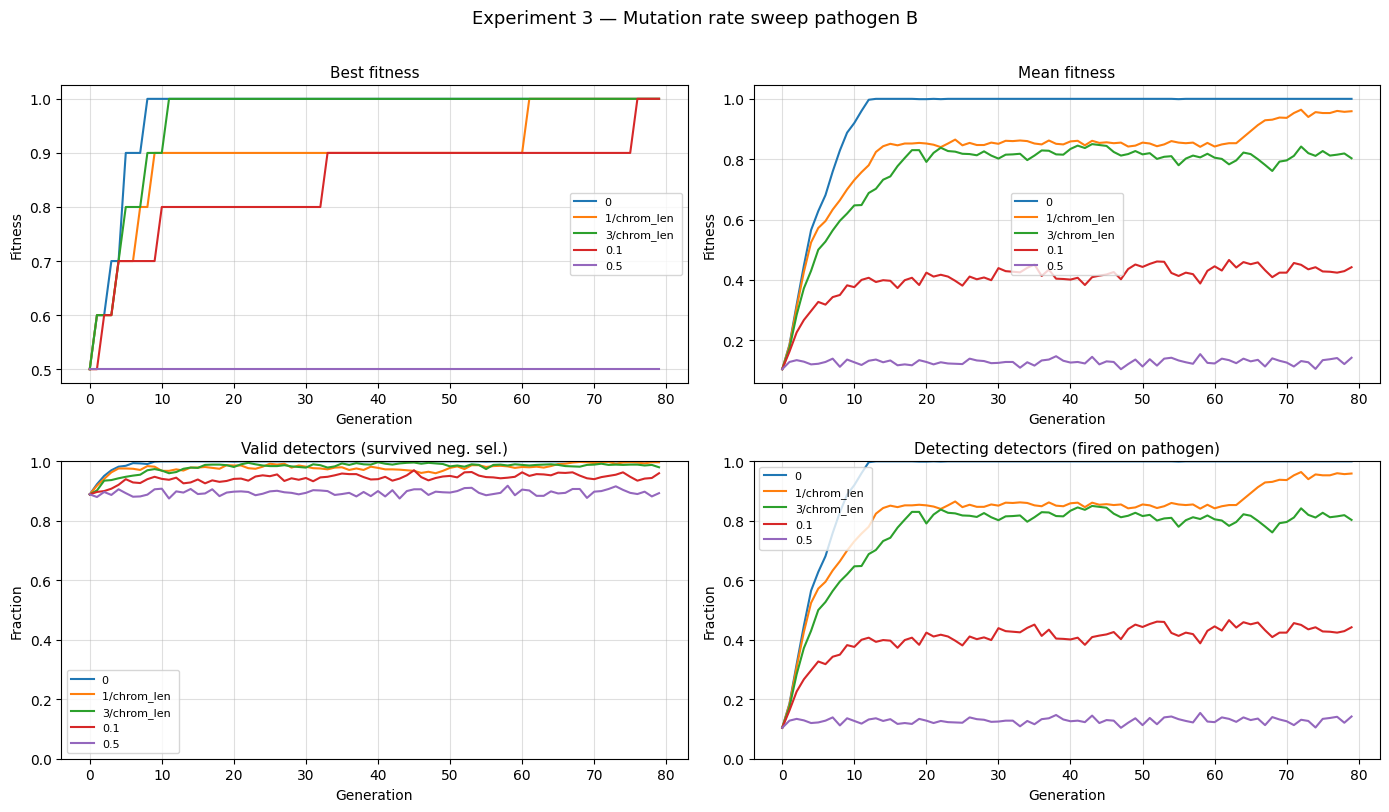

In [12]:
chrom_len = BASE["detector_length"] * BASE["detectors_per_ind"]

mutation_rates = {
    "0 ":        0.0,
    "1/chrom_len ": 1.0 / (2 * chrom_len),
    "1/chrom_len ":  1.0 / chrom_len,
    "3/chrom_len":      3.0 / chrom_len,
    "0.1": 0.1,
    "0.5": 0.5,
}

mut_results = {}
for label, rate in mutation_rates.items():
    mut_results[label] = run_ga(
        pathogen      = PAT_B,
        self_str      = SELF,
        generations   = 80,
        mutation_rate = rate,
        **BASE,
    )

plot_four_metrics(mut_results, "Experiment 3 — Mutation rate sweep pathogen B", filename='experiment3_mutation_rate_sweep.png')